# Run B — YOLO26n with a ZipDepth encoder backbone on KITTI

The YOLO26n backbone (layers 0–10, including SPPF and C2PSA) is replaced by the depth-pretrained ZipDepth-base encoder;
the YOLO26n neck and head are kept and initialised from COCO exactly as in Run A. 1×1 Conv-BN-SiLU adapters map the
encoder outputs (96 / 192 / 384 channels at strides 8 / 16 / 32) to the channels the neck expects (128 / 128 / 256).
Training uses the locked `exp_config.yaml` of Run A unchanged (same optimizer and learning rate for all parameters, no
freezing), so the backbone is the only difference between the runs.

**Flow:** build the model → sanity checks → overfit/checkpoint/resume test on 32 images → *all checks must pass* →
full training (skipped if a finished run exists) → evaluation of A and B with identical code in the same session →
comparison table.

**Requires on Drive** (from Run A): `exp_config.yaml`, `runs/A_yolo26n/`. **Writes:** `zipdepth_yolo.py`, `runs/B_zipdepth/`, `results/results_B.json`,
`results/comparison_AB.csv`. Loading `B_zipdepth/weights/*.pt` later needs `zipdepth_yolo.py` and the ZipDepth repo
on `sys.path` (the checkpoint pickles the model classes).

## 1. Setup

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "ultralytics>=8.4"], check=True)

In [2]:
import os, json, time, copy, random, shutil, importlib
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, yaml
from PIL import Image

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT, DATA_ROOT, WORK = Path("/content/drive/MyDrive/lab"), Path("/content/datasets"), Path("/content")
else:
    ROOT, DATA_ROOT, WORK = Path("lab_drive").resolve(), Path("datasets").resolve(), Path(".").resolve()
os.chdir(WORK)

# ZipDepth repo: clone only (its requirements.txt would reinstall torch)
ZD_DIR = WORK / "ZipDepth"
if not ZD_DIR.exists():
    subprocess.run(["git", "clone", "-q", "https://github.com/fabiotosi92/ZipDepth.git", str(ZD_DIR)], check=True)
ZD_CKPT = ZD_DIR / "checkpoints/zipdepth_base.pth"
for p in (str(ZD_DIR), str(WORK)):
    if p not in sys.path:
        sys.path.insert(0, p)

import ultralytics
from ultralytics import YOLO

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE != "cpu" else "CPU"
SMOKE = DEVICE == "cpu"                        # CPU: pipeline check only
RUN_A, RUN_B = ("A_yolo26n_smoke", "B_zipdepth_smoke") if SMOKE else ("A_yolo26n", "B_zipdepth")
pd.set_option("display.precision", 3)
print(f"torch {torch.__version__} | ultralytics {ultralytics.__version__} | {GPU_NAME} | SMOKE={SMOKE} | runs {RUN_A} vs {RUN_B}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch 2.11.0+cu128 | ultralytics 8.4.164 | Tesla T4 | SMOKE=False | runs A_yolo26n vs B_zipdepth


## 2. Data and configuration

Same data, label table (`cache/kitti_labels.csv`) and locked configuration as Run A. The configuration is read from
Drive, not redefined. `lab_eval.py` is identical to the version written by the Run A notebook.

In [3]:
%%writefile lab_eval.py
"""lab_eval.py - shared evaluation utilities for runs A / B / C (YOLO26n vs ZipDepth backbone on KITTI).

Every run is evaluated with this file, unchanged, so that all numbers in the comparison table
come from identical code.
"""
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics.utils.metrics import ap_per_class, box_iou

# 10 IoU thresholds of mAP50-95, built exactly like Ultralytics (float32) so that ">= threshold" matches bit for bit.
IOUV = torch.linspace(0.5, 0.95, 10).numpy()

# Size buckets by ground-truth box height in original image pixels (25 px = KITTI minimum height for Moderate/Hard).
SIZE_BUCKETS = {"small (<25px)": (0.0, 25.0), "medium (25-50px)": (25.0, 50.0), "large (>=50px)": (50.0, float("inf"))}


# ----------------------------------------------------------------------------- labels
def bucket_of(h):
    for name, (lo, hi) in SIZE_BUCKETS.items():
        if lo <= h < hi:
            return name
    return list(SIZE_BUCKETS)[0]


def build_label_df(kitti_dir, names, splits=("train", "val")):
    """One row per ground-truth object: split, image, image size, class, normalised and pixel box, height, bucket."""
    rows = []
    for split in splits:
        for img in sorted((Path(kitti_dir) / "images" / split).glob("*.png")):
            W, H = Image.open(img).size
            lbl = Path(kitti_dir) / "labels" / split / (img.stem + ".txt")
            if not lbl.exists() or lbl.stat().st_size == 0:
                continue
            for c, xc, yc, w, h in np.loadtxt(lbl, ndmin=2):
                rows.append((split, img.name, str(img), W, H, int(c), xc, yc, w, h))
    df = pd.DataFrame(rows, columns=["split", "image", "path", "img_w", "img_h", "cls", "xc", "yc", "w", "h"])
    df["name"] = df["cls"].map(names)
    df["x1"] = (df.xc - df.w / 2) * df.img_w
    df["y1"] = (df.yc - df.h / 2) * df.img_h
    df["x2"] = (df.xc + df.w / 2) * df.img_w
    df["y2"] = (df.yc + df.h / 2) * df.img_h
    df["h_px"] = df.y2 - df.y1
    df["bucket"] = df.h_px.map(bucket_of)
    return df


def load_label_df(kitti_dir, names, cache_path):
    """Build the label table once and cache it as CSV (e.g. on Drive)."""
    cache_path = Path(cache_path)
    if cache_path.exists():
        return pd.read_csv(cache_path)
    df = build_label_df(kitti_dir, names)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(cache_path, index=False)
    return df


# ----------------------------------------------------------------------------- matching
def match_with_index(pred_cls, gt_cls, iou):
    """Greedy matching identical to Ultralytics DetectionValidator.match_predictions(use_scipy=False),
    but returning the matched gt index. iou: (L gt, D det). Returns (D, 10) int array, -1 = unmatched."""
    D, L = len(pred_cls), len(gt_cls)
    out = -np.ones((D, len(IOUV)), int)
    if D == 0 or L == 0:
        return out
    iou = iou * (gt_cls[:, None] == pred_cls[None, :])
    for i, t in enumerate(IOUV):
        m = np.array(np.nonzero(iou >= t)).T
        if m.shape[0]:
            if m.shape[0] > 1:
                m = m[iou[m[:, 0], m[:, 1]].argsort()[::-1]]
                m = m[np.unique(m[:, 1], return_index=True)[1]]
                m = m[np.unique(m[:, 0], return_index=True)[1]]
            out[m[:, 1], i] = m[:, 0]
    return out


def make_record(pred_boxes, pred_cls, pred_conf, gt_cls, gt_boxes):
    L, D = len(gt_boxes), len(pred_boxes)
    iou = (box_iou(torch.as_tensor(gt_boxes, dtype=torch.float32), torch.as_tensor(pred_boxes, dtype=torch.float32)).numpy()
           if L and D else np.zeros((L, D), np.float32))
    pred_cls, gt_cls = np.asarray(pred_cls, int), np.asarray(gt_cls, int)
    return dict(conf=np.asarray(pred_conf, np.float32), pcls=pred_cls,
                ph=(pred_boxes[:, 3] - pred_boxes[:, 1]) if D else np.zeros(0),
                match=match_with_index(pred_cls, gt_cls, iou),
                gcls=gt_cls, gh=(gt_boxes[:, 3] - gt_boxes[:, 1]) if L else np.zeros(0))


@torch.no_grad()
def collect_predictions(model, gt_df, imgsz=640, device=None, conf=0.001, iou=0.7, max_det=300):
    """Batch-1 prediction on every image in gt_df (same thresholds as model.val()), one record per image."""
    recs = []
    for path, g in gt_df.groupby("path", sort=True):
        r = model.predict(path, imgsz=imgsz, conf=conf, iou=iou, max_det=max_det, device=device, verbose=False)[0]
        b = r.boxes
        recs.append(make_record(b.xyxy.cpu().numpy(), b.cls.cpu().numpy().astype(int), b.conf.cpu().numpy(),
                                g.cls.values, g[["x1", "y1", "x2", "y2"]].values.astype(np.float32)))
    return recs


# ----------------------------------------------------------------------------- AP per size bucket
def _in(h, lo, hi):
    return ((h >= lo) | (lo <= 0)) & (h < hi)


def bucket_ap(recs, nc, lo=0.0, hi=float("inf")):
    """COCO-style AP restricted to gt boxes with height in [lo, hi).
    TP: matched a gt in the bucket. Ignored: matched a gt outside the bucket, or unmatched with its own height outside.
    FP: unmatched and inside the bucket. With (0, inf) this equals Ultralytics' mAP computation exactly.
    Returns ap (nc, 10) with NaN for classes without gt in the bucket, and n_gt (nc,)."""
    ap = np.full((nc, len(IOUV)), np.nan)
    n_gt = np.zeros(nc, int)
    for r in recs:
        n_gt += np.bincount(r["gcls"][_in(r["gh"], lo, hi)], minlength=nc)[:nc]
    for t in range(len(IOUV)):
        confs, pcls, tps, tcls = [], [], [], []
        for r in recs:
            m, in_gt, in_pred = r["match"][:, t], _in(r["gh"], lo, hi), _in(r["ph"], lo, hi)
            matched = m >= 0
            tp = np.zeros(len(m), bool)
            tp[matched] = in_gt[m[matched]]
            keep = ~((matched & ~tp) | (~matched & ~in_pred))
            confs.append(r["conf"][keep]); pcls.append(r["pcls"][keep]); tps.append(tp[keep]); tcls.append(r["gcls"][in_gt])
        tcls = np.concatenate(tcls)
        if len(tcls):
            res = ap_per_class(np.concatenate(tps)[:, None], np.concatenate(confs), np.concatenate(pcls), tcls)
            ap[res[6].astype(int), t] = res[5][:, 0]
    return dict(ap=ap, n_gt=n_gt)


def size_table(recs, names):
    """Rows: all + size buckets. Columns: n_gt, mAP50, mAP50-95, AP50-95 per class."""
    rows = []
    for bucket, (lo, hi) in {"all": (0.0, float("inf")), **SIZE_BUCKETS}.items():
        r = bucket_ap(recs, len(names), lo, hi)
        ok = ~np.isnan(r["ap"][:, 0])
        row = {"bucket": bucket, "n_gt": int(r["n_gt"].sum()),
               "mAP50": float(r["ap"][ok, 0].mean()) if ok.any() else np.nan,
               "mAP50-95": float(r["ap"][ok].mean()) if ok.any() else np.nan}
        row.update({names[c]: float(r["ap"][c].mean()) for c in range(len(names))})
        rows.append(row)
    return pd.DataFrame(rows).set_index("bucket")


# ----------------------------------------------------------------------------- features
def pca_rgb(fmap):
    """(C, H, W) feature map -> (H, W, 3) image of the top-3 principal components, and their explained variance."""
    C, H, W = fmap.shape
    X = fmap.reshape(C, -1).T.double()
    X = X - X.mean(0)
    U, S, _ = torch.linalg.svd(X, full_matrices=False)
    pcs = (U[:, :3] * S[:3]).numpy()
    lo, hi = np.percentile(pcs, 1, axis=0), np.percentile(pcs, 99, axis=0)
    img = np.clip((pcs - lo) / (hi - lo + 1e-12), 0, 1).reshape(H, W, 3)
    return img, float((S[:3] ** 2).sum() / (S ** 2).sum())


# ----------------------------------------------------------------------------- cost
def count_params(module):
    return sum(p.numel() for p in module.parameters())


@torch.no_grad()
def measure_latency(net, shape, device, half=False, warmup=30, iters=200):
    """Network forward time in ms (no pre/post-processing, no NMS)."""
    net = net.to(device).eval()
    x = torch.rand(*shape, device=device)
    if half:
        net, x = net.half(), x.half()
    for _ in range(warmup):
        net(x)
    times = []
    if str(device).startswith("cuda"):
        torch.cuda.synchronize()
        for _ in range(iters):
            s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
            s.record(); net(x); e.record(); torch.cuda.synchronize()
            times.append(s.elapsed_time(e))
    else:
        for _ in range(iters):
            t0 = time.perf_counter(); net(x); times.append((time.perf_counter() - t0) * 1000)
    if half:
        net.float()
    t = np.array(times)
    return dict(mean=float(t.mean()), median=float(np.median(t)), p90=float(np.percentile(t, 90)))


@torch.no_grad()
def peak_inference_memory(net, shape, device, half=False):
    """Peak GPU memory (MiB) of one forward pass: total and above the weights."""
    if not str(device).startswith("cuda"):
        return dict(total_mib=float("nan"), activations_mib=float("nan"))
    net = net.to(device).eval()
    x = torch.rand(*shape, device=device)
    if half:
        net, x = net.half(), x.half()
    torch.cuda.synchronize(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
    base = torch.cuda.memory_allocated(device)
    net(x); torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated(device)
    if half:
        net.float()
    return dict(total_mib=peak / 2**20, activations_mib=(peak - base) / 2**20)


def save_json(obj, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(json.dumps(obj, indent=2, ensure_ascii=False, default=float))

Overwriting lab_eval.py


In [4]:
KITTI_DIR = DATA_ROOT / "kitti"
if not (KITTI_DIR / "images/val").exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    subprocess.run(["wget", "-q", "-O", str(DATA_ROOT / "kitti.zip"),
                    "https://github.com/ultralytics/assets/releases/download/v0.0.0/kitti.zip"], check=True)
    subprocess.run(["unzip", "-q", "-o", str(DATA_ROOT / "kitti.zip"), "-d", str(KITTI_DIR)], check=True)
    (DATA_ROOT / "kitti.zip").unlink()
NAMES = {0: "car", 1: "van", 2: "truck", 3: "pedestrian", 4: "Person_sitting", 5: "cyclist", 6: "tram", 7: "misc"}
DATA_YAML = DATA_ROOT / "kitti.yaml"
_ = DATA_YAML.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": "images/train", "val": "images/val",
                                         "names": NAMES}, sort_keys=False))

assert (ROOT / "exp_config.yaml").exists(), "exp_config.yaml missing on Drive: run the Run A notebook first"
shutil.copy(WORK / "lab_eval.py", ROOT / "lab_eval.py")         # same shared evaluator as the Run A notebook
import lab_eval; importlib.reload(lab_eval)
from lab_eval import (SIZE_BUCKETS, load_label_df, collect_predictions, size_table, pca_rgb, count_params,
                      measure_latency, peak_inference_memory, save_json)

EXP = yaml.safe_load((ROOT / "exp_config.yaml").read_text())
assert EXP["data"] == str(DATA_YAML), (EXP["data"], DATA_YAML)
labels = load_label_df(KITTI_DIR, NAMES, ROOT / "cache/kitti_labels.csv")
val = labels[labels.split == "val"]
SMALL = list(SIZE_BUCKETS)[0]

if SMOKE:                                      # same 300-image val subset as the Run A smoke run
    keep = sorted(random.Random(0).sample(sorted(val.path.unique()), 300))
    (DATA_ROOT / "kitti_smoke_val.txt").write_text("\n".join(keep) + "\n")
    RUN_DATA = DATA_ROOT / "kitti_smoke.yaml"
    RUN_DATA.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": "images/train",
                                        "val": str(DATA_ROOT / "kitti_smoke_val.txt"), "names": NAMES}, sort_keys=False))
    val = val[val.path.isin(keep)]
    SMOKE_OVERRIDES = dict(epochs=2, fraction=0.02, data=str(RUN_DATA), cache=False, batch=4, workers=0)  # fits 8 GB RAM
else:
    RUN_DATA, SMOKE_OVERRIDES = DATA_YAML, {}
RUNS = ROOT / "runs"
assert (RUNS / RUN_A / "weights/best.pt").exists(), "Run A weights not found"
pd.DataFrame([{**EXP, **SMOKE_OVERRIDES}]).T.astype(str).rename(columns={0: "value"})

,value
data,/content/datasets/kitti.yaml
imgsz,640
epochs,50
batch,16
seed,0
deterministic,True
optimizer,SGD
lr0,0.01
lrf,0.01
momentum,0.937


## 3. Model

`zipdepth_yolo.py` builds the standard 8-class YOLO26n, loads COCO weights with the same call the trainer uses for
Run A, then replaces layers 0–10: layer 0 becomes `ZipDepthBackbone` (normalisation + encoder + adapters), layers
4 / 6 / 10 pick P3 / P4 / P5 from its output list, and the remaining backbone indices become pass-through
placeholders, so the neck's layer references stay valid. `ZipDepthTrainer` plugs the model into the standard
Ultralytics trainer (and restores it from the checkpoint on resume).

In [5]:
%%writefile zipdepth_yolo.py
"""zipdepth_yolo.py - YOLO26n with its backbone (layers 0-10) replaced by the ZipDepth encoder.

Kept in a separate module so that checkpoints (which pickle the model) can be loaded from any notebook,
provided this file and the ZipDepth repo are on sys.path.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.nn.tasks import DetectionModel
from zipdepth.model.architecture import create_model

YOLO_OUT_CH = (128, 128, 256)          # channels YOLO26n's neck expects at P3 / P4 / P5
REPLACED = range(0, 11)                # YOLO26n backbone layers (0-10) replaced by the encoder


class SafeBatchNorm2d(nn.BatchNorm2d):
    """BatchNorm2d that falls back to running statistics when a channel has a single value in training
    (the encoder's GlobalContextBlock applies BN to a pooled 1x1 vector, which fails for a final batch of 1 image)."""

    def forward(self, x):
        if self.training and x.numel() // x.shape[1] == 1:
            return F.batch_norm(x, self.running_mean, self.running_var, self.weight, self.bias, False, 0.0, self.eps)
        return super().forward(x)


class ZipDepthBackbone(nn.Module):
    """ImageNet-normalised ZipDepth encoder + 1x1 Conv-BN-SiLU adapters. Input in [0, 1]; returns [P3, P4, P5]."""

    def __init__(self, ckpt=None, out_channels=YOLO_OUT_CH):
        super().__init__()
        zd = create_model("base", upsample_unfold=True)
        if ckpt is not None:
            zd.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=True))
        self.encoder = zd.encoder                                   # decoder is discarded
        for m in self.encoder.modules():                            # same parameters, safe for batch-1 steps
            if type(m) is nn.BatchNorm2d:
                m.__class__ = SafeBatchNorm2d
        self.register_buffer("mean", zd.mean.clone())
        self.register_buffer("std", zd.std.clone())
        enc_ch = (self.encoder.stage2[0].out_ch, self.encoder.stage3[0].out_ch, self.encoder.stage4[0].out_ch)
        self.adapters = nn.ModuleList(
            nn.Sequential(nn.Conv2d(ci, co, 1, bias=False), nn.BatchNorm2d(co), nn.SiLU())
            for ci, co in zip(enc_ch, out_channels))

    def encode(self, x):
        """Raw encoder outputs (s2, s3', s4') at strides 8 / 16 / 32."""
        _, (_, s2, s3, s4) = self.encoder((x - self.mean) / self.std)
        return s2, s3, s4

    def forward(self, x):
        return [a(f) for a, f in zip(self.adapters, self.encode(x))]


class Pick(nn.Module):
    """Selects one tensor from the backbone's output list (keeps the neck's layer indices valid)."""

    def __init__(self, idx):
        super().__init__()
        self.idx = idx

    def forward(self, x):
        return x[self.idx]


class PassThrough(nn.Module):
    """Placeholder for a removed backbone layer; its output is never consumed."""

    def forward(self, x):
        return x


def _set_meta(m, i, f):
    m.i, m.f, m.type, m.np = i, f, type(m).__name__, sum(p.numel() for p in m.parameters())
    return m


def build_zipdepth_yolo(nc, names, zipdepth_ckpt=None, coco_weights="yolo26n.pt", verbose=False):
    """YOLO26n (nc classes) with COCO neck/head weights and a ZipDepth backbone.

    zipdepth_ckpt=None gives a randomly initialised encoder (run C). Layer indices 0-10 are kept:
    layer 0 = ZipDepthBackbone, layers 4 / 6 / 10 pick P3 / P4 / P5 from it, the rest are placeholders.
    """
    model = DetectionModel("yolo26n.yaml", nc=nc, verbose=False)
    model.names = names
    if coco_weights:                                                # same transfer as run A (incl. cls_remap)
        from ultralytics import YOLO
        model.load(YOLO(coco_weights).model, verbose=verbose)
    layers = list(model.model)
    layers[0] = _set_meta(ZipDepthBackbone(zipdepth_ckpt), 0, -1)
    for i in REPLACED[1:]:
        layers[i] = _set_meta(PassThrough(), i, -1)
    layers[4] = _set_meta(Pick(0), 4, 0)
    layers[6] = _set_meta(Pick(1), 6, 0)
    layers[10] = _set_meta(Pick(2), 10, 0)
    model.model = nn.Sequential(*layers)
    model.save = sorted(set(model.save) | {0})                     # keep layer 0's output for layers 4 / 6 / 10
    model.yaml["backbone_override"] = "ZipDepth-base encoder" + (" (pretrained)" if zipdepth_ckpt else " (random)")
    return model


class ZipDepthTrainer(DetectionTrainer):
    """DetectionTrainer that builds the ZipDepth model; on resume it restores weights from the checkpoint model."""

    zipdepth_ckpt = None                                             # set before training (None = random encoder)

    def get_model(self, cfg=None, weights=None, verbose=True):
        model = build_zipdepth_yolo(self.data["nc"], self.data["names"], self.zipdepth_ckpt,
                                    coco_weights=None if weights is not None else "yolo26n.pt", verbose=verbose)
        if weights is not None:                                      # resume / fine-tune from a saved run
            model.load_state_dict(weights.float().state_dict())
        return model


def fuse_zipdepth_yolo(model):
    """Inference fusion: RepVGG blocks of the encoder + Ultralytics Conv/BN fusion of neck and head."""
    model.model[0].encoder.fuse()
    return model.fuse(verbose=False)

Overwriting zipdepth_yolo.py


In [6]:
shutil.copy(WORK / "zipdepth_yolo.py", ROOT / "zipdepth_yolo.py")
import zipdepth_yolo; importlib.reload(zipdepth_yolo)
from zipdepth_yolo import build_zipdepth_yolo, fuse_zipdepth_yolo, ZipDepthTrainer, ZipDepthBackbone
from zipdepth.model.architecture import create_model
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils.torch_utils import intersect_dicts

model_B = build_zipdepth_yolo(len(NAMES), NAMES, ZD_CKPT).eval()
coco = YOLO("yolo26n.pt").model.float()
model_A0 = DetectionModel("yolo26n.yaml", nc=len(NAMES), verbose=False)   # Run A's starting point
model_A0.names = NAMES
model_A0.load(coco, verbose=False); model_A0.eval()

def part_params(m):
    # Parameters per part; the ZipDepth backbone is split into encoder and adapters
    out = {"backbone: encoder": 0, "backbone: adapters": 0, "backbone: YOLO layers": 0, "neck (11-22)": 0, "head (23)": 0}
    for i, layer in enumerate(m.model):
        if isinstance(layer, ZipDepthBackbone):
            out["backbone: encoder"] += count_params(layer.encoder); out["backbone: adapters"] += count_params(layer.adapters)
        else:
            out["backbone: YOLO layers" if i <= 10 else "neck (11-22)" if i <= 22 else "head (23)"] += count_params(layer)
    return out

params_init = pd.DataFrame({"Run A": part_params(model_A0), "Run B": part_params(model_B)})
params_init.loc["total"] = params_init.sum()
params_init["B / A"] = (params_init["Run B"] / params_init["Run A"]).replace(np.inf, np.nan)
params_init.style.format({"Run A": "{:,.0f}", "Run B": "{:,.0f}", "B / A": "{:.2f}"}, na_rep="—")

Overriding model.yaml nc=80 with nc=8
Overriding model.yaml nc=80 with nc=8


,Run A,Run B,B / A
backbone: encoder,0,"6,634,249",—
backbone: adapters,0,"136,192",—
backbone: YOLO layers,"1,365,472",0,0.00
neck (11-22),"897,152","897,152",1.00
head (23),"244,296","244,296",1.00
total,"2,506,920","7,911,889",3.16


## 4. Sanity checks

| # | Check | Pass condition |
|---|---|---|
| 1 | Backbone output shapes | P3/P4/P5 of B equal the shapes of YOLO26n layers 4/6/10 (640×640 and 224×640) |
| 2 | Detection output | same output shape as Run A's model |
| 3 | Encoder weights | every encoder tensor equals `zipdepth_base.pth` |
| 4 | Encoder output | encoder inside B reproduces the original ZipDepth model's s2 / s3′ / s4′ on a KITTI image |
| 5 | Neck/head init | every COCO-initialised neck/head tensor equals Run A's starting model |
| 6 | Gradient flow | one training step gives non-zero gradients to encoder, adapters, neck and head |
| 6b | Batch of one image | a training step with a single image runs (the last batch of each epoch has 1 image) |

In [46]:
checks = {}
def grab(net, idx):
    # Forward hooks storing the outputs of layers idx; returns (hooks, dict)
    feats = {}
    hooks = [net.model[i].register_forward_hook(lambda m, a, o, i=i: feats.__setitem__(i, o)) for i in idx]
    return hooks, feats

# 1-2: shapes against Run A's model
with torch.no_grad():
    for h, w in [(640, 640), (224, 640)]:
        x = torch.rand(1, 3, h, w)
        hooks, fa = grab(model_A0, (4, 6, 10)); ya = model_A0(x); [k.remove() for k in hooks]
        pb = model_B.model[0](x); yb = model_B(x)
        checks[f"1. P3/P4/P5 shapes @{h}x{w}"] = [tuple(fa[i].shape) for i in (4, 6, 10)] == [tuple(t.shape) for t in pb]
        checks[f"2. detection output @{h}x{w}"] = tuple(ya[0].shape) == tuple(yb[0].shape)

# 3: encoder weights == checkpoint
sd = torch.load(ZD_CKPT, map_location="cpu", weights_only=True)
enc = {k[len("encoder."):]: v for k, v in sd.items() if k.startswith("encoder.")}
mine = model_B.model[0].encoder.state_dict()
checks[f"3. encoder tensors == checkpoint ({len(enc)})"] = enc.keys() == mine.keys() and all(torch.equal(enc[k], mine[k]) for k in enc)

# 4: encoder output == original ZipDepth
zd = create_model("base", upsample_unfold=True); zd.load_state_dict(sd); zd.eval()
img_path = val.path.iloc[0]
x = torch.from_numpy(np.array(Image.open(img_path).convert("RGB").resize((640, 192)))).permute(2, 0, 1)[None].float() / 255
with torch.no_grad():
    _, (_, s2, s3, s4) = zd.encoder((x - zd.mean) / zd.std)
    ours = model_B.model[0].encode(x)
diffs = [float((a - b).abs().max()) for a, b in zip((s2, s3, s4), ours)]
checks["4. encoder output == ZipDepth (max |diff| %.1e)" % max(diffs)] = max(diffs) < 1e-5

# 5: neck/head init identical to Run A (tensors copied from COCO)
copied = set(intersect_dicts(coco.state_dict(), model_A0.state_dict()))
sa, sb = model_A0.state_dict(), model_B.state_dict()
nh = [k for k in copied if int(k.split(".")[1]) >= 11]
checks[f"5. neck/head COCO tensors == Run A ({len(nh)})"] = all(torch.equal(sa[k], sb[k]) for k in nh)

# 6: one training step on real images -> gradients everywhere
from ultralytics.cfg import get_cfg
m = copy.deepcopy(model_B).train(); m.args = get_cfg()
imgs = sorted(labels[labels.split == "train"].path.unique())[:4]
g = labels[labels.path.isin(imgs)]
batch = dict(img=torch.stack([torch.from_numpy(np.array(Image.open(p).convert("RGB").resize((640, 640)))).permute(2, 0, 1)
                              for p in imgs]).float() / 255,
             batch_idx=torch.tensor([imgs.index(p) for p in g.path], dtype=torch.float32),
             cls=torch.tensor(g.cls.values, dtype=torch.float32)[:, None],
             bboxes=torch.tensor(g[["xc", "yc", "w", "h"]].values, dtype=torch.float32))
loss, _ = m.loss(batch); loss.sum().backward()
def grad_frac(mod):
    ps = [p for p in mod.parameters() if p.requires_grad]
    return sum(p.grad is not None and bool(p.grad.abs().sum() > 0) for p in ps) / len(ps)
gf = {"encoder": grad_frac(m.model[0].encoder), "adapters": grad_frac(m.model[0].adapters),
      "neck": grad_frac(torch.nn.ModuleList(m.model[11:23])), "head": grad_frac(m.model[23])}
checks["6. gradient flow (" + ", ".join(f"{k} {100 * v:.0f}%" for k, v in gf.items()) + ")"] = \
    min(gf["encoder"], gf["adapters"], gf["neck"]) > 0.99 and gf["head"] > 0.5

# 6b: a training step with a single image (the last batch of an epoch: 5985 = 374 x 16 + 1)
m.zero_grad()
one = {k: (v[:1] if k == "img" else v[batch["batch_idx"] == 0]) for k, v in batch.items()}
one["batch_idx"] = torch.zeros(len(one["cls"]))
try:
    m.loss(one)[0].sum().backward(); ok = True
except Exception as e:
    ok = False; print("batch-1 step failed:", e)
checks["6b. training step with batch size 1"] = ok
del m, zd, coco

check_df = pd.DataFrame({"check": list(checks), "passed": list(checks.values())})
check_df

,check,passed
0,1. P3/P4/P5 shapes @640x640,True
1,2. detection output @640x640,True
2,1. P3/P4/P5 shapes @224x640,True
3,2. detection output @224x640,True
4,3. encoder tensors == checkpoint (232),True
5,4. encoder output == ZipDepth (max |diff| 0.0e...,True
6,5. neck/head COCO tensors == Run A (366),True
7,"6. gradient flow (encoder 100%, adapters 100%,...",True
8,6b. training step with batch size 1,True


Gradient flow is the share of parameter tensors with a non-zero gradient after one step on four training images.
Encoder, adapters and neck must be at 100 %. The head can be lower by design: each pyramid level's box branch only
receives gradient when the assigner places an object on that level, and the one-to-one assigner (one anchor per
object) may assign none of the objects in these four images to P5 (in the local run: `one2one_cv2.2`, 12 % of the head
tensors).

## 5. Overfit, checkpoint and resume test

Both models are trained for 100 epochs on the same 32 training images and validated on those same images (no
augmentation, `nbs` = batch so every batch is an optimizer step). Pass condition for B: train box and cls losses drop
by at least 50 % and mAP50 on the training images is clearly above zero (≥ 0.1). Run A's model, trained with the same
settings, is shown as a reference, not as a threshold: B starts with random adapters and a neck trained on YOLO
features, so it is expected to fit more slowly (in a 320-px CPU trial: A 0.78 vs B 0.31 mAP50 after 60 epochs, with
B's losses down 80–90 %). Run B's run is
interrupted after epoch 2 (exception raised in `on_model_save`) and resumed from `last.pt`, which also exercises
checkpoint pickling, loading and the trainer's final validation of `best.pt`. Runs are written to a scratch folder
outside Drive.

In [47]:
TINY = sorted(labels[labels.split == "train"].path.unique())[:32]
(WORK / "kitti_tiny.txt").write_text("\n".join(TINY) + "\n")
TINY_YAML = WORK / "kitti_tiny.yaml"
TINY_YAML.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": str(WORK / "kitti_tiny.txt"),
                                     "val": str(WORK / "kitti_tiny.txt"), "names": NAMES}, sort_keys=False))
CHECK_DIR = WORK / "checks"; shutil.rmtree(CHECK_DIR, ignore_errors=True)
OVERFIT = dict(data=str(TINY_YAML), epochs=3 if SMOKE else 100, imgsz=320 if SMOKE else 640, batch=8 if SMOKE else 16,
               nbs=8 if SMOKE else 16, optimizer="SGD", lr0=0.01, momentum=0.937, warmup_epochs=1, seed=0, workers=0 if SMOKE else 2,
               mosaic=0.0, fliplr=0.0, scale=0.0, translate=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, erasing=0.0,
               close_mosaic=0, plots=False, device=DEVICE, project=str(CHECK_DIR), exist_ok=True, verbose=False)
INTERRUPT_AT = 2 if not SMOKE else 1

class Interrupt(Exception):
    pass

def stop_at(tr):
    # Simulated disconnect right after the checkpoint of epoch INTERRUPT_AT is written
    if tr.epoch + 1 == INTERRUPT_AT:
        raise Interrupt

t0 = time.time()
YOLO("yolo26n.pt").train(name="A_overfit", **OVERFIT)
t_a = time.time() - t0

ZipDepthTrainer.zipdepth_ckpt = str(ZD_CKPT)
t0 = time.time()
mb = YOLO("yolo26n.yaml"); mb.add_callback("on_model_save", stop_at)
try:
    mb.train(trainer=ZipDepthTrainer, name="B_overfit", **OVERFIT)
except Interrupt:
    ck = torch.load(CHECK_DIR / "B_overfit/weights/last.pt", map_location="cpu", weights_only=False)
    checks["7. interrupted run saved an unfinished checkpoint"] = ck["epoch"] == INTERRUPT_AT - 1
YOLO(str(CHECK_DIR / "B_overfit/weights/last.pt")).train(trainer=ZipDepthTrainer, resume=True)
t_b = time.time() - t0
print(f"overfit runs: A {t_a / 60:.1f} min, B {t_b / 60:.1f} min")

New https://pypi.org/project/ultralytics/8.4.165 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti_tiny.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937,

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      2.87G      3.553      9.018    0.02211         55        640: 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9it/s 0.3s
                   all         32        130          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/100      2.87G      3.515      9.711    0.02172         56        640: 0% ──────────── 0/2  0.2s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      2.87G      3.647      8.984    0.02244         74        640: 100% ━━━━━━━━━━━━ 2/2 4.1it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.8it/s 0.3s
                   all         32        130          0          0          0          0
New https://pypi.org/project/ultralytics/8.4.165 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti_tiny.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropou

...

     98/100      2.94G     0.3773      1.266  0.0009968         58        640: 100% ━━━━━━━━━━━━ 2/2 4.0it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.5it/s 0.3s
                   all         32        130      0.873      0.179      0.274      0.194

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
     99/100      2.94G     0.4167      1.389  0.0008837         56        640: 0% ──────────── 0/2  0.3s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     99/100      2.94G     0.3483      1.197  0.0008012         74        640: 100% ━━━━━━━━━━━━ 2/2 3.9it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.8it/s 0.3s
                   all         32        130      0.864      0.179      0.275      0.195

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
    100/100      2.94G     0.2839       1.28  0.0005773         62        640: 0% ──────────── 0/2  0.3s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/100      2.94G     0.2665      1.152  0.0005503         68        640: 100% ━━━━━━━━━━━━ 2/2 3.6it/s 0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.8it/s 0.3s
                   all         32        130      0.855      0.179      0.275      0.195

98 epochs completed in 0.042 hours.
Optimizer stripped from /content/checks/B_overfit/weights/last.pt, 16.2MB
Optimizer stripped from /content/checks/B_overfit/weights/best.pt, 16.2MB

Validating /content/checks/B_overfit/weights/best.pt...
Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 199 layers, 7,785,549 parameters, 0 gradients, 19.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
                   all         32        130      0.856      0.179      0.275      0.195
Speed: 0.1ms preprocess, 32.9ms inference, 0.0ms

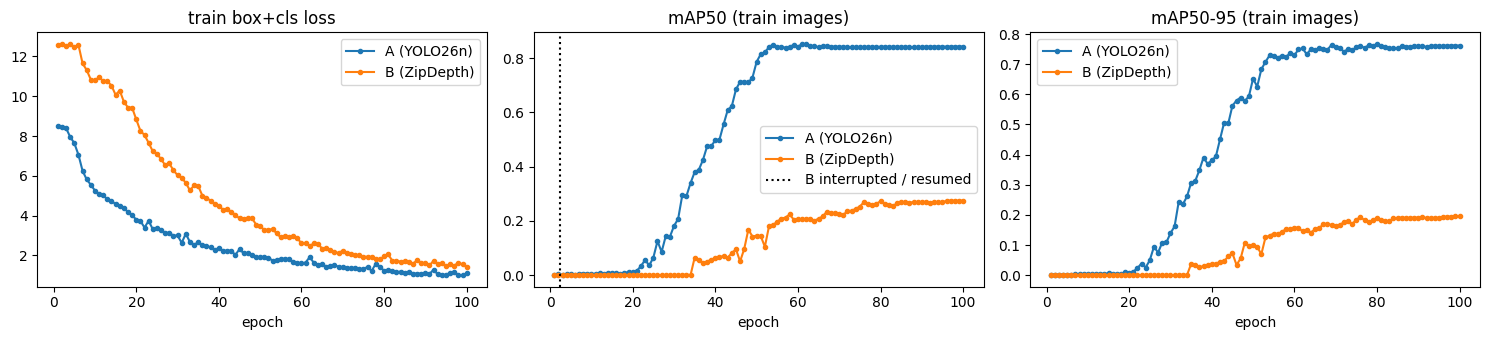

,check,passed
0,1. P3/P4/P5 shapes @640x640,True
1,2. detection output @640x640,True
2,1. P3/P4/P5 shapes @224x640,True
3,2. detection output @224x640,True
4,3. encoder tensors == checkpoint (232),True
5,4. encoder output == ZipDepth (max |diff| 0.0e...,True
6,5. neck/head COCO tensors == Run A (366),True
7,"6. gradient flow (encoder 100%, adapters 100%,...",True
8,6b. training step with batch size 1,True
9,7. interrupted run saved an unfinished checkpoint,True


In [48]:
ra = pd.read_csv(CHECK_DIR / "A_overfit/results.csv"); rb = pd.read_csv(CHECK_DIR / "B_overfit/results.csv")
ra.columns = [c.strip() for c in ra.columns]; rb.columns = [c.strip() for c in rb.columns]

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for r, lbl in [(ra, "A (YOLO26n)"), (rb, "B (ZipDepth)")]:
    ax[0].plot(r.epoch, r["train/box_loss"] + r["train/cls_loss"], ".-", label=lbl)
    ax[1].plot(r.epoch, r["metrics/mAP50(B)"], ".-", label=lbl)
    ax[2].plot(r.epoch, r["metrics/mAP50-95(B)"], ".-", label=lbl)
ax[1].axvline(INTERRUPT_AT + 0.5, color="k", ls=":", label="B interrupted / resumed")
for a, t in zip(ax, ["train box+cls loss", "mAP50 (train images)", "mAP50-95 (train images)"]):
    a.set_title(t); a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

best_b = YOLO(str(CHECK_DIR / "B_overfit/weights/best.pt"))            # reload from disk
det = best_b.predict(TINY[0], imgsz=OVERFIT["imgsz"], verbose=False)[0]
final = {k: r["metrics/mAP50(B)"].iloc[-1] for k, r in (("A", ra), ("B", rb))}
checks["7. resumed run completed all epochs"] = list(rb.epoch) == list(range(1, OVERFIT["epochs"] + 1))
checks["7. best.pt reloads as ZipDepth model and predicts"] = isinstance(best_b.model.model[0], ZipDepthBackbone) and det.boxes is not None
drop = {c: 1 - rb[f"train/{c}"].iloc[-1] / rb[f"train/{c}"].iloc[0] for c in ("box_loss", "cls_loss")}
checks[f"8. B learns: train loss -{100 * drop['box_loss']:.0f}% box / -{100 * drop['cls_loss']:.0f}% cls, "
       f"mAP50 {final['B']:.2f} (A {final['A']:.2f})"] = SMOKE or (min(drop.values()) >= 0.5 and final["B"] >= 0.1)
check_df = pd.DataFrame({"check": list(checks), "passed": list(checks.values())})
check_df

In [49]:
assert all(checks.values()), "sanity checks failed - fix before training:\n" + check_df[~check_df.passed].to_string()
print("all checks passed")

all checks passed


## 6. Training

Same logic as Run A: skipped if `runs/B_zipdepth/weights/last.pt` is finished, resumed if unfinished, otherwise
trained with the locked configuration via `ZipDepthTrainer`. The callback logs time, peak GPU memory and effective
batch per epoch.

In [8]:
run_dir = RUNS / RUN_B
last_pt, best_pt, epoch_log = run_dir / "weights/last.pt", run_dir / "weights/best.pt", run_dir / "epoch_log.csv"

def add_logging_callbacks(model):
    state = {}
    def start(tr):
        state["t0"] = time.time()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
    def end(tr):
        cuda = torch.cuda.is_available()
        row = dict(epoch=tr.epoch + 1, train_seconds=time.time() - state["t0"], batch=tr.batch_size,
                   peak_alloc_mib=torch.cuda.max_memory_allocated() / 2**20 if cuda else 0.0,
                   peak_reserved_mib=torch.cuda.max_memory_reserved() / 2**20 if cuda else 0.0)
        pd.DataFrame([row]).to_csv(epoch_log, mode="a", header=not epoch_log.exists(), index=False)
    model.add_callback("on_train_epoch_start", start)
    model.add_callback("on_train_epoch_end", end)
    return model

ZipDepthTrainer.zipdepth_ckpt = str(ZD_CKPT)
finished = last_pt.exists() and torch.load(last_pt, map_location="cpu", weights_only=False).get("epoch", -1) == -1
if finished:
    print(f"finished run found, training skipped: {run_dir}")
elif last_pt.exists():
    add_logging_callbacks(YOLO(str(last_pt))).train(trainer=ZipDepthTrainer, resume=True)
else:
    args = {**EXP, **SMOKE_OVERRIDES, "project": str(RUNS), "name": RUN_B, "exist_ok": True, "device": DEVICE}
    add_logging_callbacks(YOLO("yolo26n.yaml")).train(trainer=ZipDepthTrainer, **args)
assert best_pt.exists()

finished run found, training skipped: /content/drive/MyDrive/lab/runs/B_zipdepth


## 7. Training curves (A vs B)

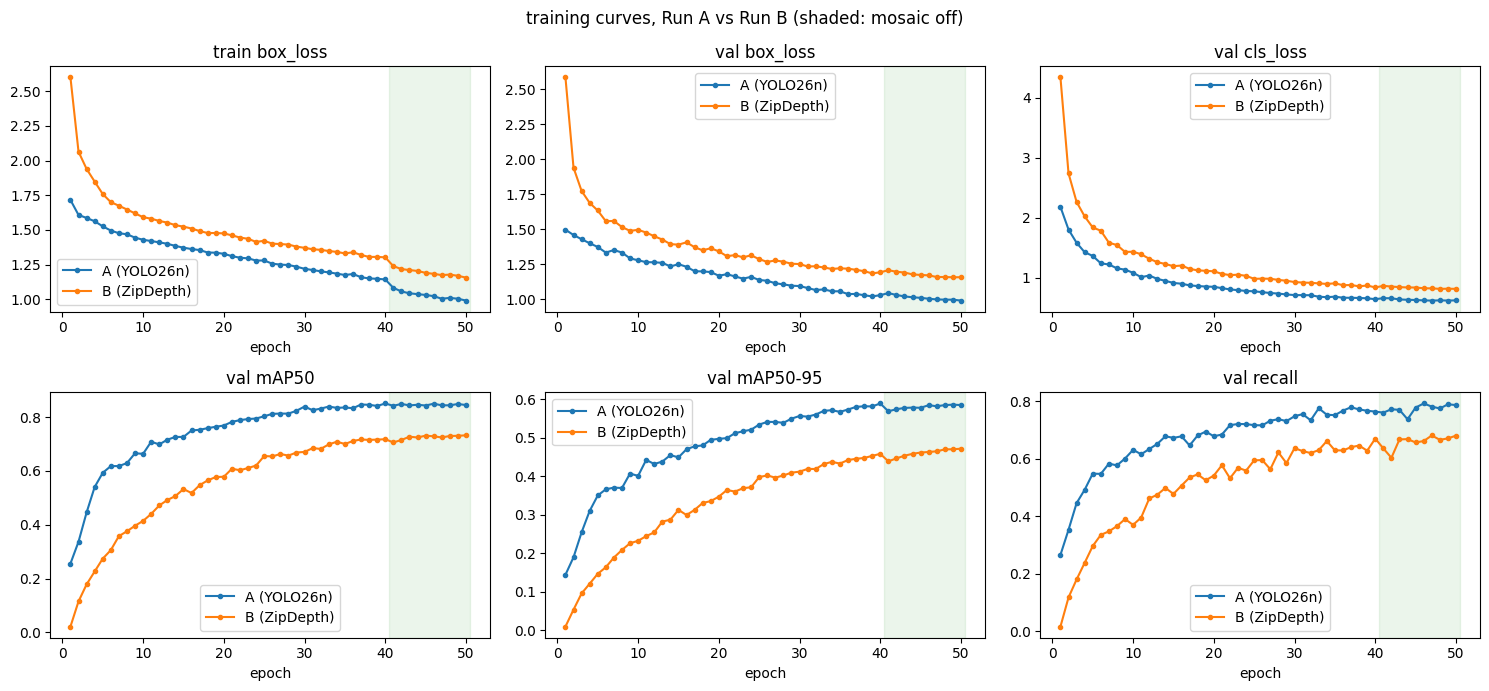

,Run A,Run B
epochs,50,50
best epoch,40,50
best mAP50-95,0.5896,0.4719
last mAP50-95,0.5855,0.4719
"mAP50-95 slope, last 5 ep",0.000486,0.002235
val box_loss min epoch,50,49
train s/epoch,103.8,104.5
peak train mem alloc (MiB),2423,2829
batch (effective),16,16


In [9]:
def read_run(name):
    d = RUNS / name
    r = pd.read_csv(d / "results.csv"); r.columns = [c.strip() for c in r.columns]
    e = pd.read_csv(d / "epoch_log.csv").drop_duplicates("epoch", keep="last") if (d / "epoch_log.csv").exists() else None
    return r, e

(res_a, elog_a), (res_b, elog_b) = read_run(RUN_A), read_run(RUN_B)
mosaic_off = {**EXP, **SMOKE_OVERRIDES}["epochs"] - EXP["close_mosaic"] + 0.5

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
panels = [("train/box_loss", "train box_loss"), ("val/box_loss", "val box_loss"), ("val/cls_loss", "val cls_loss"),
          ("metrics/mAP50(B)", "val mAP50"), ("metrics/mAP50-95(B)", "val mAP50-95"), ("metrics/recall(B)", "val recall")]
for a, (col, title) in zip(ax.flat, panels):
    for r, lbl in [(res_a, "A (YOLO26n)"), (res_b, "B (ZipDepth)")]:
        a.plot(r.epoch, r[col], ".-", label=lbl)
    a.axvspan(max(mosaic_off, 0.5), max(len(res_a), len(res_b)) + 0.5, color="green", alpha=.08)
    a.set_title(title); a.set_xlabel("epoch"); a.legend()
fig.suptitle("training curves, Run A vs Run B (shaded: mosaic off)"); plt.tight_layout(); plt.show()

def curve_summary(r, e):
    m = r["metrics/mAP50-95(B)"].values; k = min(5, len(m) - 1)
    return {"epochs": len(r), "best epoch": int(r.epoch[m.argmax()]), "best mAP50-95": m.max(), "last mAP50-95": m[-1],
            f"mAP50-95 slope, last {k} ep": np.polyfit(np.arange(k), m[-k:], 1)[0] if k >= 2 else np.nan,
            "val box_loss min epoch": int(r.epoch[r["val/box_loss"].values.argmin()]),
            "train s/epoch": e.train_seconds.mean() if e is not None else np.nan,
            "peak train mem alloc (MiB)": e.peak_alloc_mib.max() if e is not None else np.nan,
            "batch (effective)": int(e.batch.iloc[-1]) if e is not None else np.nan}
curves = pd.DataFrame({"Run A": curve_summary(res_a, elog_a), "Run B": curve_summary(res_b, elog_b)})
curves.style.format("{:.4g}")

## 8. Evaluation

Both `best.pt` files are evaluated here with identical code: Ultralytics validation (per-class AP) and the
size-bucket AP of `lab_eval`. Δ = B − A.

In [27]:
overall

{'A': {'mAP50': 0.8485998767540288,
  'mAP50_95': 0.5879936702135479,
  'P': 0.8636667471237103,
  'R': 0.7619197364849619},
 'B': {'mAP50': 0.7309021773318438,
  'mAP50_95': 0.47177886119864504,
  'P': 0.7497455786923269,
  'R': 0.6785479583974311}}

In [28]:
MODELS = {"A": YOLO(str(RUNS / RUN_A / "weights/best.pt")), "B": YOLO(str(best_pt))}
n_gt = val.groupby("cls").size()
per_class, overall, val_speed = {}, {}, {}
for k, mdl in MODELS.items():
    mt = mdl.val(data=str(RUN_DATA), imgsz=EXP["imgsz"], batch=EXP["batch"], device=DEVICE, plots=True,
                 project=str(RUNS / (RUN_A if k == "A" else RUN_B)), name="val_best", exist_ok=True, verbose=False)
    per_class[k] = pd.DataFrame([dict(cls=NAMES[int(c)], **dict(zip(["P", "R", "AP50", "AP50-95"], mt.box.class_result(i))))
                                 for i, c in enumerate(mt.box.ap_class_index)]).set_index("cls")
    overall[k] = dict(mAP50=float(mt.box.map50), mAP50_95=float(mt.box.map), P=float(mt.box.mp), R=float(mt.box.mr))
    val_speed[k] = mt.speed

cmp_cls = pd.DataFrame({"n_gt": n_gt.rename(index=NAMES)})
for met in ["AP50-95", "AP50", "R"]:
    cmp_cls[f"{met} A"], cmp_cls[f"{met} B"] = per_class["A"][met], per_class["B"][met]
    cmp_cls[f"{met} Δ"] = cmp_cls[f"{met} B"] - cmp_cls[f"{met} A"]
cmp_cls.loc["all"] = [len(val), overall["A"]["mAP50_95"], overall["B"]["mAP50_95"], overall["B"]["mAP50_95"] - overall["A"]["mAP50_95"],
                      overall["A"]["mAP50"], overall["B"]["mAP50"], overall["B"]["mAP50"] - overall["A"]["mAP50"],
                      overall["A"]["R"], overall["B"]["R"], overall["B"]["R"] - overall["A"]["R"]]
cmp_cls["n_gt"] = cmp_cls["n_gt"].astype(int)
cmp_cls.round(3).style.background_gradient(subset=[c for c in cmp_cls if c.endswith("Δ")], cmap="RdYlGn", vmin=-0.1, vmax=0.1).format(precision=3)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,396 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1226.8±435.4 MB/s, size: 48.5 KB)
val: Scanning /content/datasets/kitti/labels/val.cache... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 298.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 6.2it/s 15.3s
                   all       1496       8128      0.864      0.762      0.849      0.588
Speed: 0.6ms preprocess, 2.1ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/drive/MyDrive/lab/runs/A_yolo26n/val_best
Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 199 layers, 7,785,549 parameters, 0 gradients, 19.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1553.7±497.7 MB/s, size

,n_gt,AP50-95 A,AP50-95 B,AP50-95 Δ,AP50 A,AP50 B,AP50 Δ,R A,R B,R Δ
cls,,,,,,,,,,
car,5716,0.752,0.702,-0.050,0.955,0.933,-0.022,0.893,0.870,-0.023
van,555,0.692,0.593,-0.099,0.914,0.838,-0.076,0.836,0.771,-0.065
truck,223,0.767,0.686,-0.082,0.959,0.900,-0.059,0.893,0.843,-0.050
pedestrian,921,0.398,0.291,-0.107,0.728,0.607,-0.120,0.604,0.522,-0.081
Person_sitting,36,0.349,0.228,-0.121,0.674,0.451,-0.223,0.611,0.444,-0.167
cyclist,352,0.473,0.315,-0.158,0.781,0.622,-0.159,0.685,0.562,-0.122
tram,117,0.690,0.530,-0.161,0.937,0.817,-0.121,0.884,0.838,-0.046
misc,208,0.583,0.430,-0.153,0.841,0.680,-0.162,0.690,0.577,-0.113
all,8128,0.588,0.472,-0.116,0.849,0.731,-0.118,0.762,0.679,-0.083


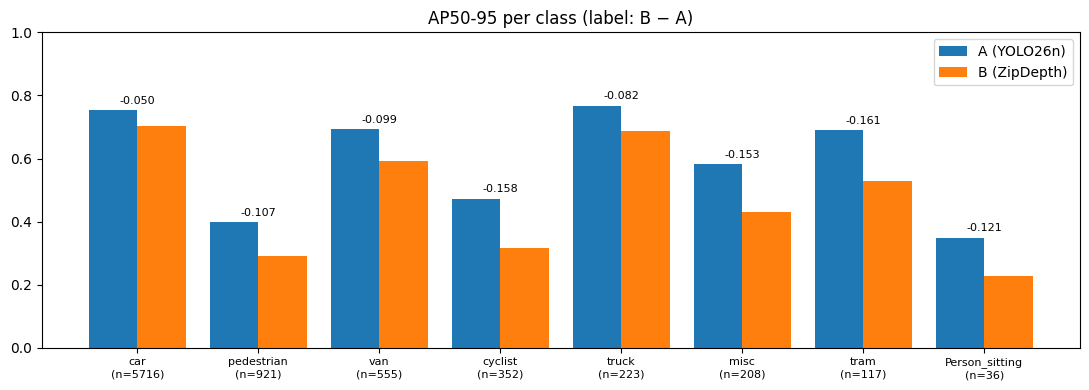

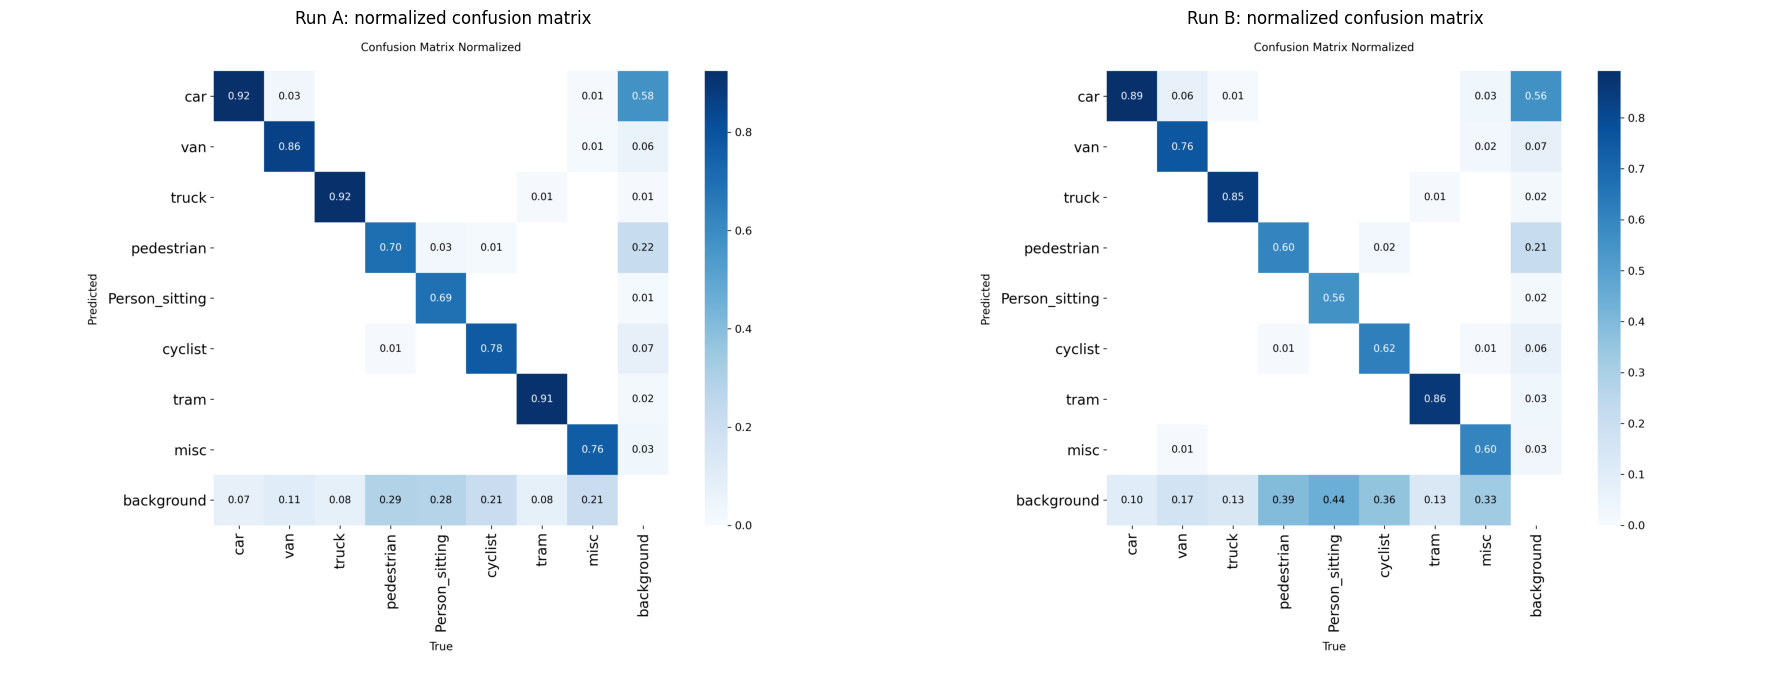

In [29]:
pc = cmp_cls.drop("all").sort_values("n_gt", ascending=False); x = np.arange(len(pc))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - .2, pc["AP50-95 A"], .4, label="A (YOLO26n)"); ax.bar(x + .2, pc["AP50-95 B"], .4, label="B (ZipDepth)")
for i, d in enumerate(pc["AP50-95 Δ"]):
    ax.text(i, max(pc["AP50-95 A"].iloc[i], pc["AP50-95 B"].iloc[i]) + .02, f"{d:+.3f}", ha="center", fontsize=8)
ax.set_xticks(x, [f"{c}\n(n={n})" for c, n in zip(pc.index, pc.n_gt)], fontsize=8); ax.set_ylim(0, 1)
ax.set_title("AP50-95 per class (label: B − A)"); ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(18, 6.8))
for a, k in zip(ax, "AB"):
    a.imshow(plt.imread(RUNS / (RUN_A if k == "A" else RUN_B) / "val_best/confusion_matrix_normalized.png")); a.axis("off")
    a.set_title(f"Run {k}: normalized confusion matrix")
plt.tight_layout(); plt.show()

## 9. AP by object size

Primary small-object metric: `car` AP50-95 in the small bucket (800 objects; the other classes have ≤ 37 small
objects).

In [12]:
size = {k: size_table(collect_predictions(mdl, val, imgsz=EXP["imgsz"], device=DEVICE), NAMES) for k, mdl in MODELS.items()}
cols = ["mAP50", "mAP50-95", "car", "van", "pedestrian", "cyclist"]
cmp_size = pd.concat({k: size[k][cols] for k in "AB"}, axis=1)
for c in cols:
    cmp_size[("Δ", c)] = cmp_size[("B", c)] - cmp_size[("A", c)]
cmp_size.insert(0, ("", "n_gt"), size["A"]["n_gt"])
cmp_size.round(3)

A                                            \
                  n_gt  mAP50 mAP50-95    car    van pedestrian cyclist   
bucket                                                                    
all               8128  0.842    0.584  0.750  0.685      0.398   0.481   
small (<25px)      889  0.530    0.306  0.550  0.371      0.024   0.195   
medium (25-50px)  2903  0.695    0.455  0.706  0.591      0.119   0.390   
large (>=50px)    4336  0.881    0.646  0.832  0.794      0.446   0.550   

                      B                                                Δ  \
                  mAP50 mAP50-95    car    van pedestrian cyclist  mAP50   
bucket                                                                     
all               0.733    0.473  0.701  0.584      0.285   0.330 -0.109   
small (<25px)     0.427    0.218  0.470  0.298      0.001   0.017 -0.103   
medium (25-50px)  0.599    0.376  0.657  0.485      0.087   0.182 -0.096   
large (>=50px)    0.781    0.530  0.792  0.701      0.322   0.427 -0.099   

                                                            
                 mAP50-95    car    van pedestrian cyclist  
bucket                                                      
all                -0.111 -0.049 -0.101     -0.112  -0.151  
small (<25px)      -0.088 -0.080 -0.074     -0.024  -0.179  
medium (25-50px)   -0.079 -0.049 -0.106     -0.033  -0.208  
large (>=50px)     -0.116 -0.040 -0.093     -0.125  -0.123

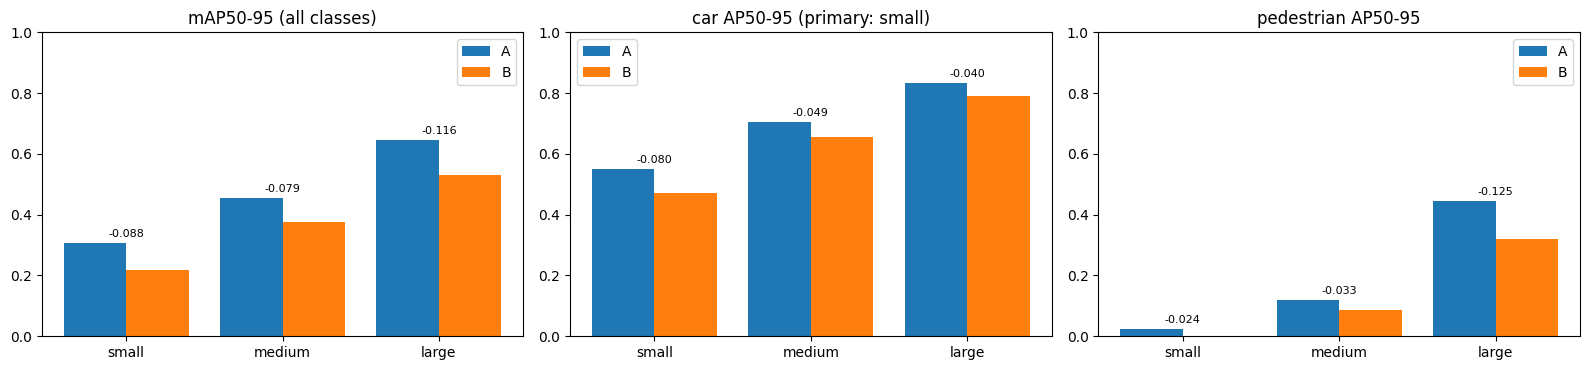

In [13]:
buckets = list(SIZE_BUCKETS); x = np.arange(len(buckets))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for a, c, t in zip(ax, ["mAP50-95", "car", "pedestrian"], ["mAP50-95 (all classes)", "car AP50-95 (primary: small)", "pedestrian AP50-95"]):
    va, vb = size["A"].loc[buckets, c], size["B"].loc[buckets, c]
    a.bar(x - .2, va, .4, label="A"); a.bar(x + .2, vb, .4, label="B")
    for i in range(len(buckets)):
        a.text(i, max(va.iloc[i], vb.iloc[i]) + .02, f"{vb.iloc[i] - va.iloc[i]:+.3f}", ha="center", fontsize=8)
    a.set_xticks(x, [b.split(" ")[0] for b in buckets]); a.set_ylim(0, 1); a.set_title(t); a.legend()
plt.tight_layout(); plt.show()

## 10. Feature maps

PCA-RGB (**top**-3 components, variance explained in the title) of the tensors each model hands to the neck (layers
4 / 6 / 10) and of the neck outputs fed to the head (layers 16 / 19 / 22), on the val image with the most small
objects (same image as in the Run A notebook), resized to 192×640.

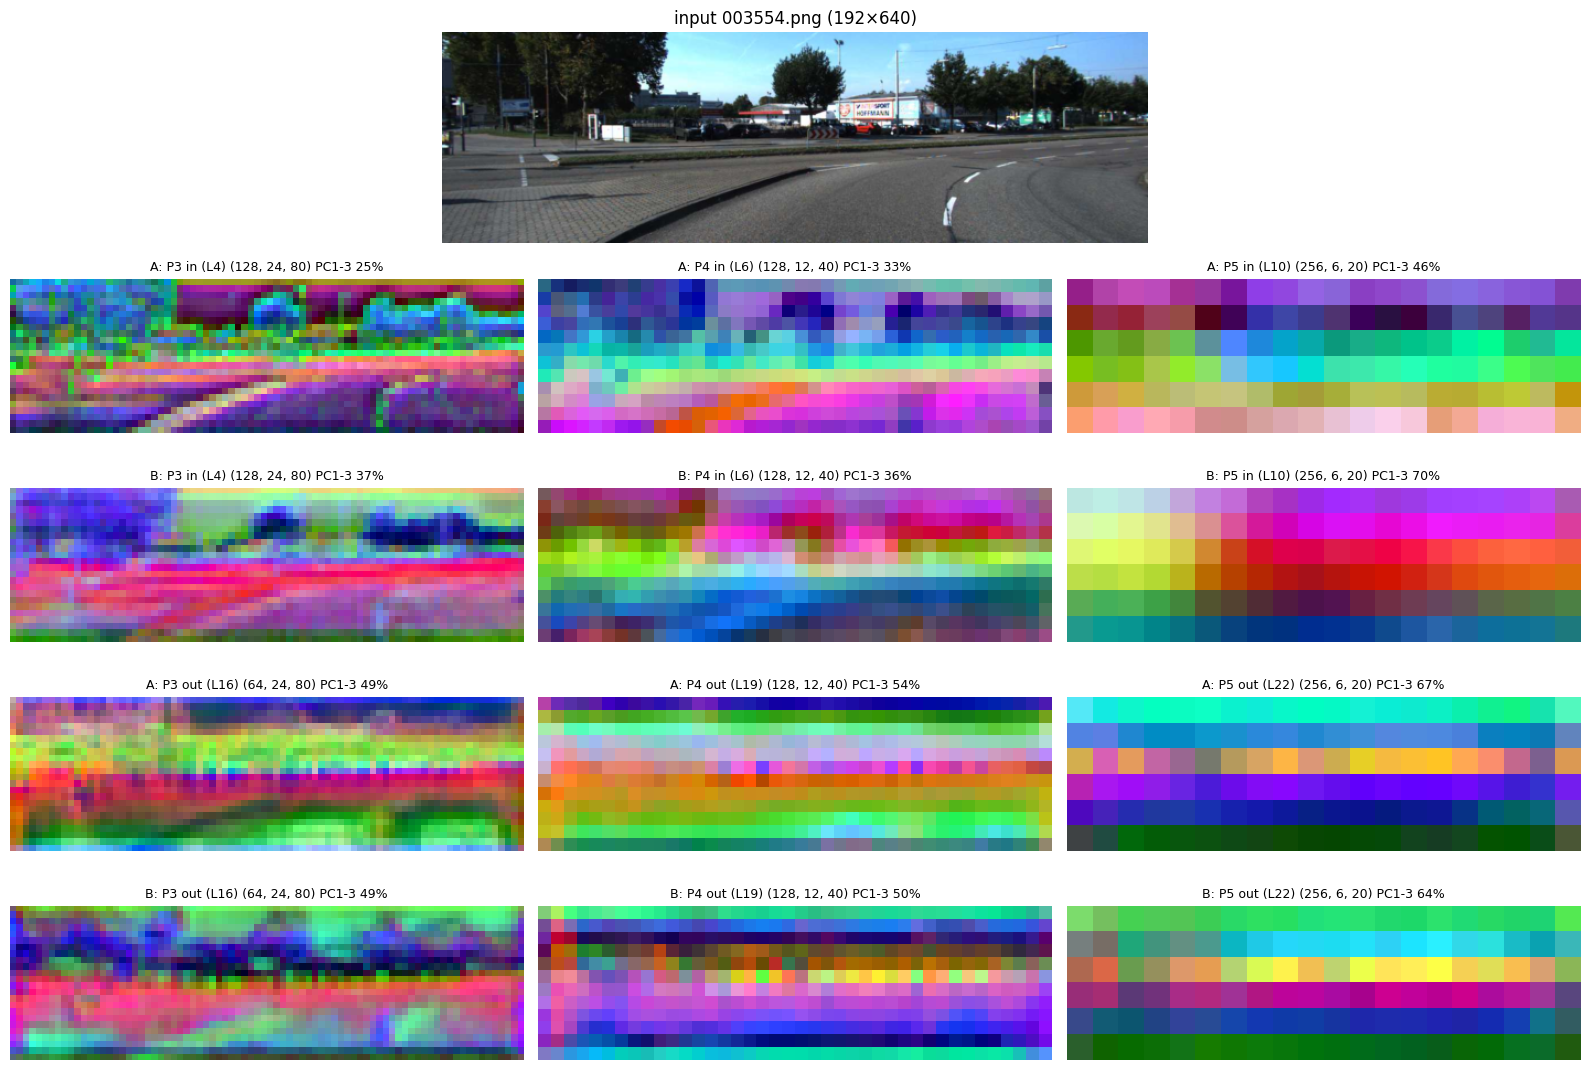

In [14]:
LAYERS = {"P3 in (L4)": 4, "P4 in (L6)": 6, "P5 in (L10)": 10, "P3 out (L16)": 16, "P4 out (L19)": 19, "P5 out (L22)": 22}
n_small = val[val.bucket == SMALL].groupby("path").size().sort_values(ascending=False)
feat_img = n_small.index[0]
rgb = np.array(Image.open(feat_img).convert("RGB").resize((640, 192), Image.BILINEAR))
x = torch.from_numpy(rgb).permute(2, 0, 1)[None].float().div(255).to(DEVICE)

def features(mdl):
    # Forward hooks on the listed layers; returns {name: (C, H, W) tensor}
    net = copy.deepcopy(mdl.model).float().eval().to(DEVICE); feats = {}
    hooks = [net.model[i].register_forward_hook(lambda m, a, o, k=k: feats.__setitem__(k, o[0].detach().float().cpu()))
             for k, i in LAYERS.items()]
    with torch.no_grad():
        net(x)
    for h in hooks:
        h.remove()
    return feats

feats = {k: features(m) for k, m in MODELS.items()}
fig = plt.figure(figsize=(16, 11)); gs = fig.add_gridspec(5, 3, height_ratios=[1.1, 1, 1, 1, 1])
a = fig.add_subplot(gs[0, :]); a.imshow(rgb); a.axis("off"); a.set_title(f"input {Path(feat_img).name} (192×640)")
pca_var = {"A": {}, "B": {}}
rows = [("A", ["P3 in (L4)", "P4 in (L6)", "P5 in (L10)"]), ("B", ["P3 in (L4)", "P4 in (L6)", "P5 in (L10)"]),
        ("A", ["P3 out (L16)", "P4 out (L19)", "P5 out (L22)"]), ("B", ["P3 out (L16)", "P4 out (L19)", "P5 out (L22)"])]
for r, (k, names_) in enumerate(rows):
    for c, n in enumerate(names_):
        img, var = pca_rgb(feats[k][n]); pca_var[k][n] = var
        ax = fig.add_subplot(gs[1 + r, c]); ax.imshow(img, interpolation="nearest"); ax.axis("off")
        ax.set_title(f"{k}: {n} {tuple(feats[k][n].shape)} PC1-3 {100 * var:.0f}%", fontsize=9)
plt.tight_layout(); plt.show()

## 11. Model cost

Both models measured back to back in this session. Fused models: Ultralytics Conv/BN fusion for both, plus RepVGG
fusion of the ZipDepth encoder for B. Latency = network forward only (no pre-processing, no NMS), 30 warm-up + 200
timed runs; throughput at batch 32 FP16. Training cost comes from each run's `epoch_log.csv`.

In [16]:
from ultralytics.utils.torch_utils import get_flops

fused = {"A": copy.deepcopy(MODELS["A"].model).float().eval().fuse(verbose=False),
         "B": fuse_zipdepth_yolo(copy.deepcopy(MODELS["B"].model).float().eval())}
cost = pd.DataFrame({k: {"params (unfused)": count_params(MODELS[k].model), "params (fused)": count_params(fused[k]),
                         "GFLOPs @640 (fused)": get_flops(fused[k], EXP["imgsz"])} for k in "AB"})

gpu = DEVICE != "cpu"
cfgs = [(1, 640, 640, False), (1, 640, 640, True), (1, 224, 640, False), (1, 224, 640, True), (32 if gpu else 4, 640, 640, gpu)]
if not gpu:
    cfgs = [c for c in cfgs if not c[3]] + [(4, 640, 640, False)]
lat = []
for k in "AB":
    for b, h, w, half in dict.fromkeys(cfgs):
        L = measure_latency(fused[k], (b, 3, h, w), DEVICE, half=half, warmup=30 if gpu else 2, iters=(200 if b == 1 else 50) if gpu else 5)
        M = peak_inference_memory(fused[k], (b, 3, h, w), DEVICE, half=half)
        lat.append(dict(run=k, batch=b, input=f"{h}x{w}", precision="FP16" if half else "FP32", median_ms=L["median"],
                        img_per_s=b * 1000 / L["median"], peak_mem_mib=M["total_mib"]))
lat_df = pd.DataFrame(lat).pivot_table(index=["batch", "input", "precision"], columns="run",
                                       values=["median_ms", "img_per_s", "peak_mem_mib"], dropna=False)
for v in ["median_ms", "img_per_s", "peak_mem_mib"]:
    lat_df[(v, "B / A")] = lat_df[(v, "B")] / lat_df[(v, "A")]
lat_df = lat_df[lat_df[("median_ms", "A")].notna()].sort_index(axis=1)
cost.loc["train s/epoch"] = [curves.loc["train s/epoch", f"Run {k}"] for k in "AB"]
cost.loc["peak train mem alloc (MiB)"] = [curves.loc["peak train mem alloc (MiB)", f"Run {k}"] for k in "AB"]
cost["B / A"] = cost["B"] / cost["A"]
print(f"device: {GPU_NAME}")
display(cost.style.format("{:,.2f}"))
lat_df.round(2)

device: Tesla T4


,A,B,B / A
params (unfused),"2,506,920.00","7,911,889.00",3.16
params (fused),"2,376,396.00","7,141,005.00",3.00
GFLOPs @640 (fused),5.32,17.82,3.35
train s/epoch,103.84,104.46,1.01
peak train mem alloc (MiB),"2,423.19","2,829.40",1.17


img_per_s               median_ms                \
run                             A       B B / A         A       B B / A   
batch input   precision                                                   
1     224x640 FP16          80.93   62.10  0.77     12.36   16.10  1.30   
              FP32          76.54   95.81  1.25     13.06   10.44  0.80   
      640x640 FP16          81.07   84.84  1.05     12.33   11.79  0.96   
              FP32          89.10   95.66  1.07     11.22   10.45  0.93   
32    640x640 FP16         512.51  317.69  0.62     62.44  100.73  1.61   

                        peak_mem_mib                
run                                A       B B / A  
batch input   precision                             
1     224x640 FP16             94.11  117.56  1.25  
              FP32            105.47  149.49  1.42  
      640x640 FP16            101.70  130.82  1.29  
              FP32            119.03  169.54  1.42  
32    640x640 FP16            465.98  786.33  1.69

## 12. Qualitative results

Same four val images as the Run A notebook. Rows per image: ground truth (red = small), Run A, Run B
(confidence ≥ 0.25).

In [20]:
SHOW

['/content/datasets/kitti/images/val/003554.png',
 '/content/datasets/kitti/images/val/000868.png',
 '/content/datasets/kitti/images/val/001490.png',
 '/content/datasets/kitti/images/val/005802.png']

In [24]:
g

,split,image,path,img_w,img_h,cls,xc,yc,w,h,name,x1,y1,x2,y2,h_px,bucket
38830,val,005802.png,/content/datasets/kitti/images/val/005802.png,1242,375,0,0.526,0.529,0.036,0.106,car,631.140,178.37,676.199,218.01,39.64,medium (25-50px)
38831,val,005802.png,/content/datasets/kitti/images/val/005802.png,1242,375,0,0.481,0.503,0.037,0.098,car,574.030,170.10,620.210,206.84,36.74,medium (25-50px)
38832,val,005802.png,/content/datasets/kitti/images/val/005802.png,1242,375,0,0.533,0.497,0.028,0.085,car,645.361,170.51,679.590,202.47,31.96,medium (25-50px)
38833,val,005802.png,/content/datasets/kitti/images/val/005802.png,1242,375,0,0.830,0.457,0.096,0.108,car,971.360,151.10,1090.231,191.53,40.43,medium (25-50px)
38834,val,005802.png,/content/datasets/kitti/images/val/005802.png,1242,375,0,0.787,0.459,0.082,0.101,car,926.550,153.32,1028.080,191.19,37.87,medium (25-50px)


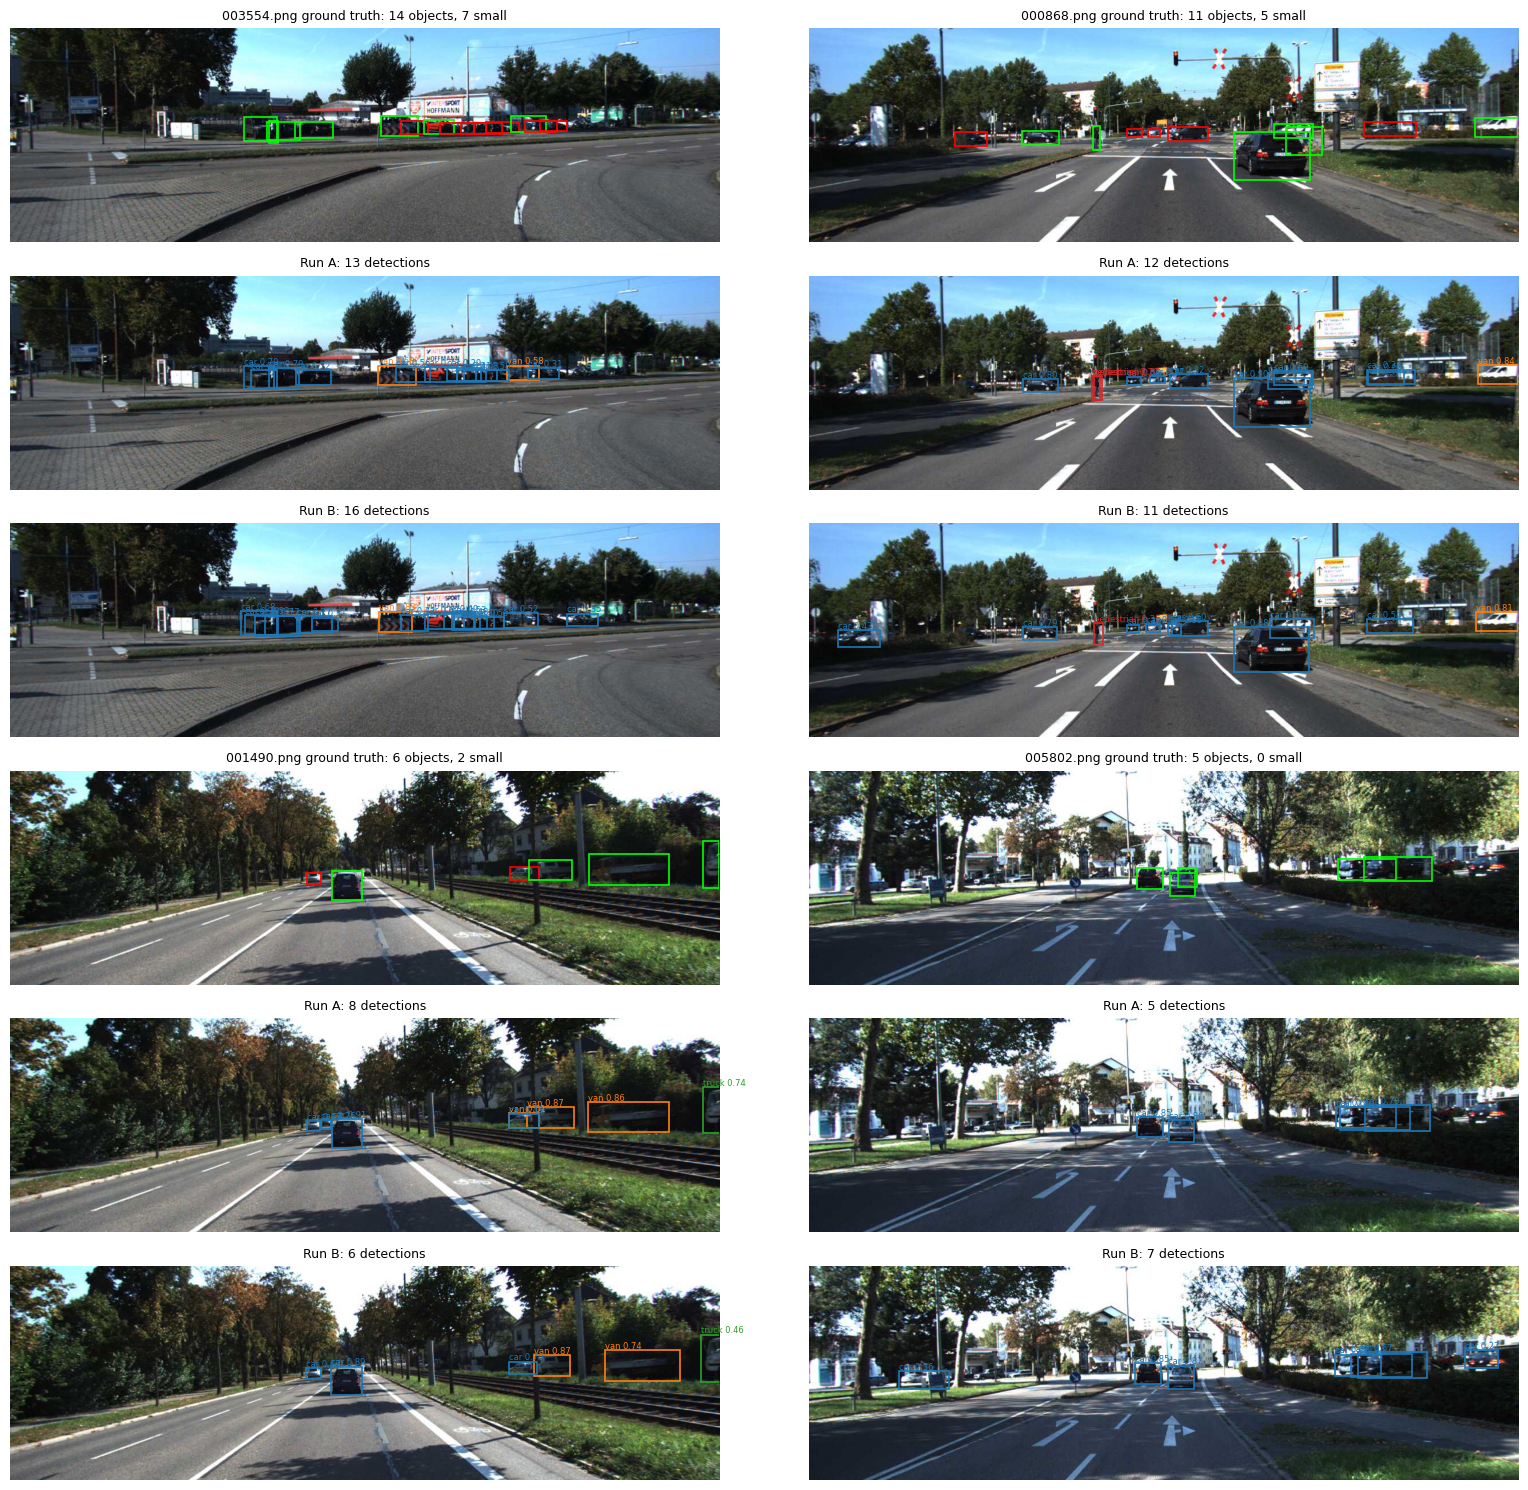

In [43]:
qfile = ROOT / "results" / ("qualitative_images_smoke.txt" if SMOKE else "qualitative_images.txt")
SHOW = [str(KITTI_DIR / "images/val" / n) for n in qfile.read_text().split()] if qfile.exists() else []
SHOW = [p for p in SHOW if p in set(val.path)] or list(n_small.index[:4])

colors = plt.cm.tab10(np.arange(len(NAMES)))
fig, axes = plt.subplots(3 * ((len(SHOW) + 1) // 2), 2, figsize=(16, 2.5 * 3 * ((len(SHOW) + 1) // 2)))
for j, p in enumerate(SHOW):
    img = np.asarray(Image.open(p).convert("RGB")); g = val[val.path == p]
    rows = axes[(j // 2) * 3:(j // 2) * 3 + 3, j % 2]
    for a in rows:
        a.imshow(img); a.axis("off")
    for _, b in g.iterrows():
        rows[0].add_patch(plt.Rectangle((b.x1, b.y1), b.x2 - b.x1, b.y2 - b.y1, fill=False, lw=1.2, ec="red" if b.bucket == SMALL else "lime"))
    rows[0].set_title(f"{Path(p).name} ground truth: {len(g)} objects, {(g.bucket == SMALL).sum()} small", fontsize=9)
    for a, k in zip(rows[1:], "AB"):
        r = MODELS[k].predict(p, imgsz=EXP["imgsz"], conf=0.25, device=DEVICE, verbose=False)[0]
        for c, s, (x1, y1, x2, y2) in zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxy.tolist()):
            a.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=colors[c], lw=1.2))
            a.text(x1, y1 - 2, f"{NAMES[c]} {s:.2f}", color=colors[c], fontsize=6)
        a.set_title(f"Run {k}: {len(r.boxes)} detections", fontsize=9)
plt.tight_layout(); plt.show()

## 13. Comparison and export

The table below is the comparison requested by the task (accuracy, parameters, speed, GPU memory). It is saved to
`results/comparison_AB.csv`; all Run B numbers (and the same-session Run A numbers) go to `results/results_B.json`.

In [50]:
b1 = lambda k, prec: lat_df.loc[(1, "640x640", prec), ("median_ms", k)]
bt = lat_df.index[-1]
row = lambda k: {
    "mAP50": overall[k]["mAP50"], "mAP50-95": overall[k]["mAP50_95"],
    "AP50-95 car": per_class[k].loc["car", "AP50-95"], "AP50-95 pedestrian": per_class[k].loc["pedestrian", "AP50-95"],
    "AP50-95 cyclist": per_class[k].loc["cyclist", "AP50-95"],
    "mAP50-95 small": size[k].loc[SMALL, "mAP50-95"], "AP50-95 car small (primary)": size[k].loc[SMALL, "car"],
    "params fused (M)": cost.loc["params (fused)", k] / 1e6, "GFLOPs @640": cost.loc["GFLOPs @640 (fused)", k],
    f"latency b1 640 {bt[2]} (ms)": b1(k, bt[2]), f"throughput b{bt[0]} {bt[2]} (img/s)": lat_df.loc[bt, ("img_per_s", k)],
    "peak inference mem b1 (MiB)": lat_df.loc[(1, "640x640", bt[2]), ("peak_mem_mib", k)],
    "peak train mem (MiB)": cost.loc["peak train mem alloc (MiB)", k], "train s/epoch": cost.loc["train s/epoch", k],
}
comparison = pd.DataFrame({"A: YOLO26n": row("A"), "B: + ZipDepth (pretrained)": row("B")})
comparison["Δ (B − A)"] = comparison.iloc[:, 1] - comparison.iloc[:, 0]
comparison["B / A"] = comparison.iloc[:, 1] / comparison.iloc[:, 0]
(ROOT / "results").mkdir(exist_ok=True)
comparison.to_csv(ROOT / "results" / ("comparison_AB_smoke.csv" if SMOKE else "comparison_AB.csv"))

results_B = dict(
    run="B", name=RUN_B, smoke=SMOKE, backbone="ZipDepth-base encoder (depth-pretrained) + adapters", gpu=GPU_NAME,
    torch=torch.__version__, ultralytics=ultralytics.__version__, config={**EXP, **SMOKE_OVERRIDES},
    sanity_checks={k: bool(v) for k, v in checks.items()},
    training={k: (v.item() if hasattr(v, "item") else v) for k, v in curves["Run B"].items()},
    overall=overall["B"], per_class=per_class["B"].reset_index().to_dict("records"),
    by_size=size["B"].reset_index().to_dict("records"), car_small_ap50_95=float(size["B"].loc[SMALL, "car"]),
    params=dict(unfused=int(cost.loc["params (unfused)", "B"]), fused=int(cost.loc["params (fused)", "B"]),
                by_part=params_init["Run B"].to_dict()),
    gflops_640=float(cost.loc["GFLOPs @640 (fused)", "B"]),
    latency=pd.DataFrame(lat).to_dict("records"), pca_var_top3=pca_var, val_speed_ms=val_speed,
    same_session_A=dict(overall=overall["A"], by_size=size["A"].reset_index().to_dict("records")),
)
save_json(results_B, ROOT / "results" / ("results_B_smoke.json" if SMOKE else "results_B.json"))
comparison.style.format("{:,.3f}")

,A: YOLO26n,B: + ZipDepth (pretrained),Δ (B − A),B / A
mAP50,0.849,0.731,-0.118,0.861
mAP50-95,0.588,0.472,-0.116,0.802
AP50-95 car,0.752,0.702,-0.050,0.934
AP50-95 pedestrian,0.398,0.291,-0.107,0.731
AP50-95 cyclist,0.473,0.315,-0.158,0.666
mAP50-95 small,0.306,0.218,-0.088,0.713
AP50-95 car small (primary),0.550,0.470,-0.080,0.854
params fused (M),2.376,7.141,4.765,3.005
GFLOPs @640,5.317,17.825,12.507,3.352
latency b1 640 FP16 (ms),12.335,11.788,-0.547,0.956
